Calcolo del flusso energetico stazionario per alpha = 0.15 al tempo: 20.0


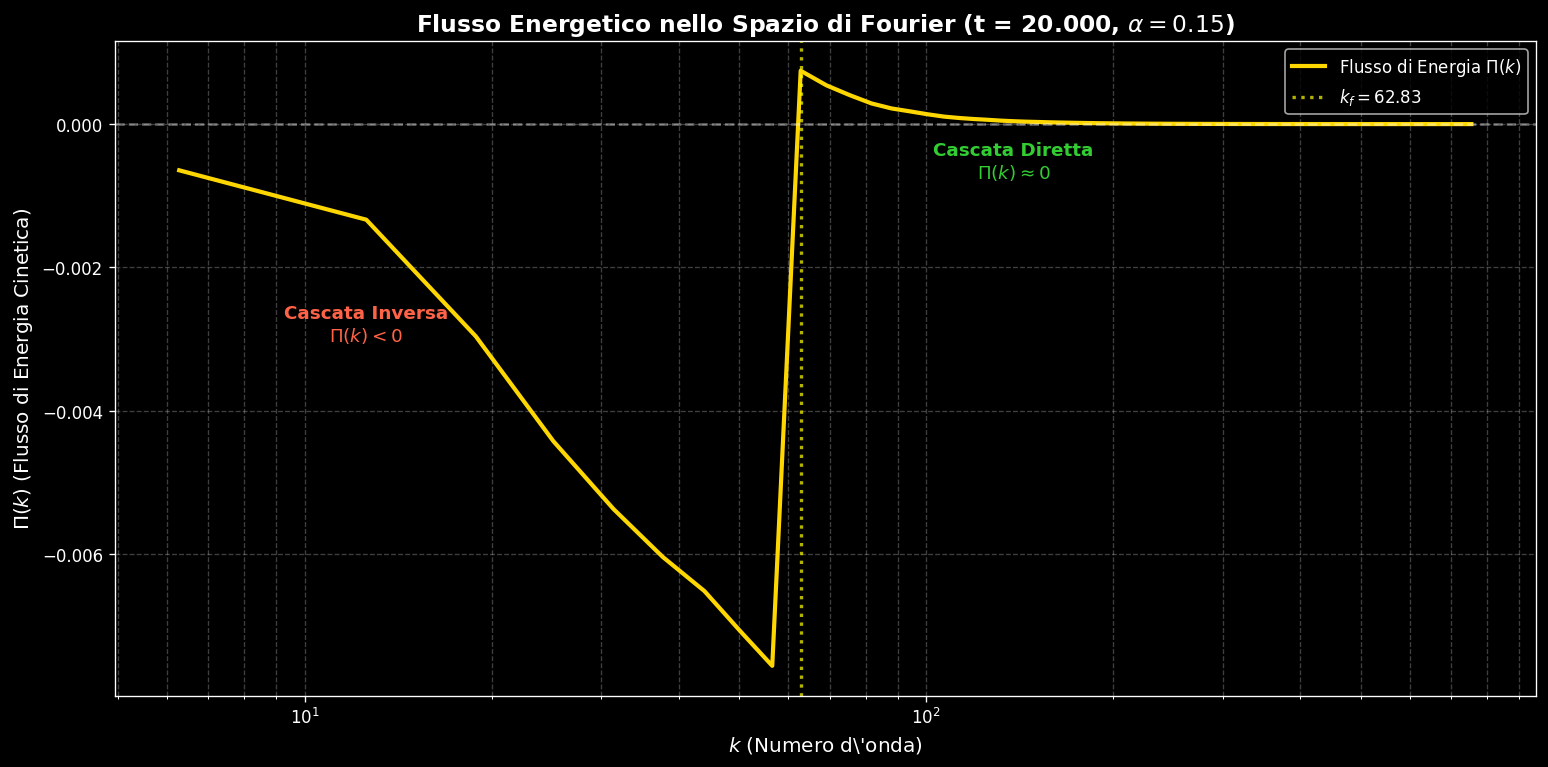

--- RECAP STATISTICO DEL BILANCIO ---
Energia totale iniettata al secondo dalla forzante: 8.834e-03
Intensità massima della cascata inversa (minimo di flusso): -7.555e-03


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =====================================================================
# PARAMETRI FISICI SINCRO_NIZZATI CON IL TUO RUN REALE
# =====================================================================
NU_SIM = 5e-5      # const double nu = 5e-5;
ALPHA_SIM = 0.15   # Attrito lineare di Ekman (alpha = 0.15)
K_F_TEORICO = 2 * np.pi * 10.0  # k_f associato al modo target 10 (~ 62.83)

PATH_SPETTRO = Path('energy_spectrum.dat')
T_CHOICE = 5.0

# --- FUNZIONE DI LETTURA ---
def read_energy_spectrum(path):
    blocks = []
    current = []
    current_time = None
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            clean = line.lstrip('#').strip()
            if clean.lower().startswith('time:'):
                if current and current_time is not None:
                    blocks.append((current_time, np.array(current)))
                    current = []
                current_time = float(clean.split(':', 1)[1].strip())
                continue
            if line.startswith('#') or current_time is None: continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    current.append([float(parts[0]), float(parts[1]), float(parts[2])])
                except ValueError: continue
    if current: blocks.append((current_time, np.array(current)))
    return blocks

# --- CARICAMENTO ---
if not PATH_SPETTRO.exists(): 
    raise FileNotFoundError(f"File non trovato: {PATH_SPETTRO.resolve()}")

blocks = read_energy_spectrum(PATH_SPETTRO)
time, data = min(blocks, key=lambda x: abs(x[0] - T_CHOICE))
print(f"Calcolo del flusso energetico stazionario per alpha = {ALPHA_SIM} al tempo: {time}")

# Estrazione delle colonne
shell_int = data[:, 0]  # Indice intero del guscio (1, 2, 3...)
k_grafico = data[:, 1]  # Numero d'onda scalato (2 * pi * shell)
E = data[:, 2]          # Spettro di energia cinetica E(k)

# =====================================================================
# CALCOLO DEL FLUSSO A POSTERIORI TRAMITE BILANCIO REALE SU GRIGLIA
# =====================================================================

# 1. Calcoliamo la dissipazione reale usando il numero d'onda fisico (l'intero)
k_fisico = shell_int
dissipazione_totale = 2.0 * NU_SIM * (k_fisico**2) * E + 2.0 * ALPHA_SIM * E

# 2. Integrazione cumulativa della dissipazione lungo le scale
flusso_ricavato = np.cumsum(dissipazione_totale)

# 3. Bilancio del Forcing stazionario sul modo target 10
idx_forzante = np.argmin(np.abs(k_fisico - 10.0))
energia_iniettata_totale = flusso_ricavato[-1]
flusso_energia = flusso_ricavato.copy()

for i in range(len(k_fisico)):
    if i >= idx_forzante:
        # Sottraiamo l'energia immessa per i modi a destra della forzante
        flusso_energia[i] -= energia_iniettata_totale

# Inversione per allineare alla convenzione fisica (flusso negativo = cascata inversa)
flusso_energia = -flusso_energia

# =====================================================================
# STRUTTURA GRAFICA DEL FLUSSO
# =====================================================================
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(13, 6.5), dpi=120)

# Plot del flusso energetico in funzione di k_grafico (2*pi*shell)
ax.plot(k_grafico, flusso_energia, color="gold", linewidth=2.5, label=r"Flusso di Energia $\Pi(k)$")

# Riferimenti geometrici (Zero e Forzante)
ax.axhline(0.0, color="white", linestyle="--", alpha=0.4)
ax.axvline(K_F_TEORICO, color='yellow', linestyle=':', linewidth=2, alpha=0.7, label=f'$k_f = {K_F_TEORICO:.2f}$')

# Annotazioni fisiche posizionate in modo pulito senza sovrapposizioni
ax.text(K_F_TEORICO * 0.2, np.min(flusso_energia) * 0.4, "Cascata Inversa\n" + r"$\Pi(k) < 0$", 
        color="tomato", fontsize=11, ha="center", fontweight="bold")
ax.text(K_F_TEORICO * 2.2, np.min(flusso_energia) * 0.1, "Cascata Diretta\n" + r"$\Pi(k) \approx 0$", 
        color="limegreen", fontsize=11, ha="center", fontweight="bold")

# Configurazione Assi Log-Linear
ax.set_xscale('log')
ax.set_xlabel(r'$k$ (Numero d\'onda)', fontsize=12)
ax.set_ylabel(r'$\Pi(k)$ (Flusso di Energia Cinetica)', fontsize=12)
ax.set_title(f'Flusso Energetico nello Spazio di Fourier (t = {time:.3f}, $\\alpha = {ALPHA_SIM}$)', fontsize=14, fontweight='bold')

ax.grid(True, which='both', linestyle='--', alpha=0.25)
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print(f"--- RECAP STATISTICO DEL BILANCIO ---")
print(f"Energia totale iniettata al secondo dalla forzante: {energia_iniettata_totale:.3e}")
print(f"Intensità massima della cascata inversa (minimo di flusso): {flusso_energia.min():.3e}")